In [30]:
!pip install opendatasets

In [31]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset")

Skipping, found downloaded files in "./amazon-sales-dataset" (use force=True to force download)


In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

As the dataset has classic CSV encoding issue, clean the dataset.

In [33]:
df = pd.read_csv("/content/amazon-sales-dataset/amazon.csv")
df.head(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [34]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [35]:
product_cols=['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product','img_link', 'product_link']

products_df = df[product_cols].drop_duplicates()

In [36]:
products_df.shape

(1465, 11)

In [37]:

reviews_df = df[['product_id','review_id','user_id','user_name','review_title','review_content']].copy()




In [38]:
# Clean missing reviews
reviews_df = reviews_df.dropna(subset=['review_content'])

In [39]:
reviews_df.shape

(1465, 6)

In [40]:
reviews_df.isna().sum()

,0
product_id,0
review_id,0
user_id,0
user_name,0
review_title,0
review_content,0


In [41]:
products_df.head(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


Fix the two price columns which stored as text, ₹.

In [42]:
products_df['discounted_price'] = products_df['discounted_price'].str.replace("₹",'')
products_df['discounted_price'] = products_df['discounted_price'].str.replace(",",'')
products_df['discounted_price'] = products_df['discounted_price'].astype('float64')

products_df['actual_price'] = products_df['actual_price'].str.replace("₹",'')
products_df['actual_price'] = products_df['actual_price'].str.replace(",",'')
products_df['actual_price'] = products_df['actual_price'].astype('float64')

convert the string rating count,discount,and rating columns into numerric values

In [43]:
products_df['discount_percentage'] = products_df['discount_percentage'].str.replace('%','').astype('float64')

products_df['discount_percentage'] = products_df['discount_percentage'] / 100

products_df['discount_percentage'].head()

,discount_percentage
0,0.64
1,0.43
2,0.90
3,0.53
4,0.61


In [44]:
# Finding unusual string in rating column
products_df['rating'].value_counts()

,count
rating,
4.1,244
4.3,230
4.2,228
4.0,129
3.9,123
4.4,123
3.8,86
4.5,75
4,52


In [45]:
products_df['rating'] = df['rating'].replace('|', '3.9').astype(float)
products_df['rating_count'] = df['rating_count'].str.replace(",","").astype(float)

In [46]:
products_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1465 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   img_link             1465 non-null   object 
 10  product_link         1465 non-null   object 
dtypes: float64(5), object(6)
memory usage: 126.0+ KB


In [47]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_id      1465 non-null   object
 1   review_id       1465 non-null   object
 2   user_id         1465 non-null   object
 3   user_name       1465 non-null   object
 4   review_title    1465 non-null   object
 5   review_content  1465 non-null   object
dtypes: object(6)
memory usage: 68.8+ KB


Summarry statistic of all product columns

In [48]:
products_df.describe(include= 'all')

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,img_link,product_link
count,1465,1465,1465,1465.000000,1465.000000,1465.000000,1465.000000,1463.000000,1465,1465,1465
unique,1351,1337,211,NaN,NaN,NaN,NaN,NaN,1293,1412,1465
top,B083342NKJ,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,NaN,NaN,NaN,NaN,NaN,[CHARGE & SYNC FUNCTION]- This cable comes wit...,https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
freq,3,5,233,NaN,NaN,NaN,NaN,NaN,6,3,1
mean,NaN,NaN,NaN,3125.310874,5444.990635,0.476915,4.096451,18295.541353,NaN,NaN,NaN
std,NaN,NaN,NaN,6944.304394,10874.826864,0.216359,0.291620,42753.864952,NaN,NaN,NaN
min,NaN,NaN,NaN,39.000000,39.000000,0.000000,2.000000,2.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,325.000000,800.000000,0.320000,4.000000,1186.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,799.000000,1650.000000,0.500000,4.100000,5179.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,1999.000000,4295.000000,0.630000,4.300000,17336.500000,NaN,NaN,NaN


Check missing values

In [49]:
products_df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
img_link,0


In [50]:
reviews_df.isnull().sum()

,0
product_id,0
review_id,0
user_id,0
user_name,0
review_title,0
review_content,0


In [51]:
products_df['rating_count'] = products_df.groupby('category')['rating_count'].transform(lambda x: x.fillna(x.median()))
products_df['rating'] = products_df.groupby('category')['rating'].transform(lambda x: x.fillna(x.median()))

In [52]:
products_df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
about_product,0
img_link,0


Splitting the category column

In [53]:
products_df["main_category"] = df["category"].str.split("|").str[0]
products_df["sub_category_1"] = df["category"].str.split("|").str[1]
products_df["sub_category_2"] = df["category"].str.split("|").str[2]
products_df["sub_category_3"] = df["category"].str.split("|").str[3]
products_df["sub_category_4"] = df["category"].str.split("|").str[4]

# **DESCRIPTIVE STATISTICS**

In [76]:
# dont show warnings
import warnings
warnings.filterwarnings('ignore')

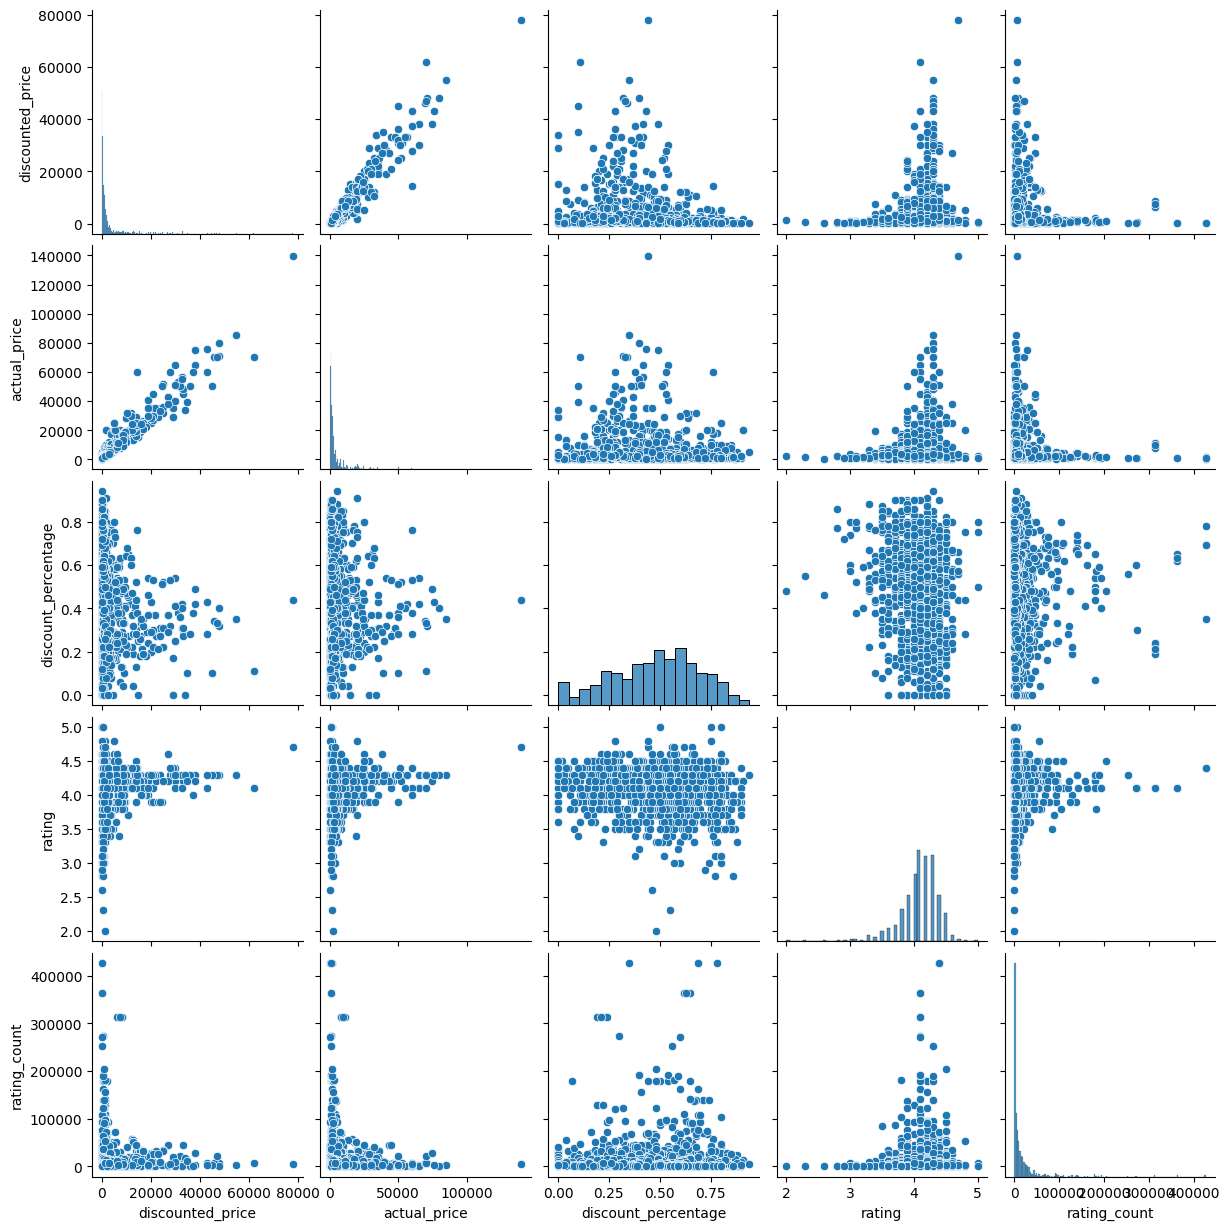

In [77]:
sns.pairplot(products_df)

Plot correlations between variables

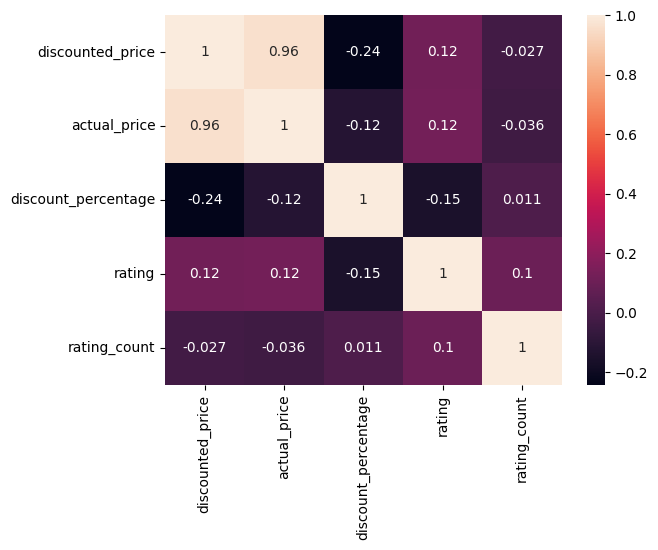

In [80]:
numeric_df = products_df.select_dtypes(include="number")
correation_matrix = numeric_df.corr()
sns.heatmap(correation_matrix,annot=True)
plt.show()

**Price Distribution?**
 understand the distribution of products actual prices and the dicountedprices

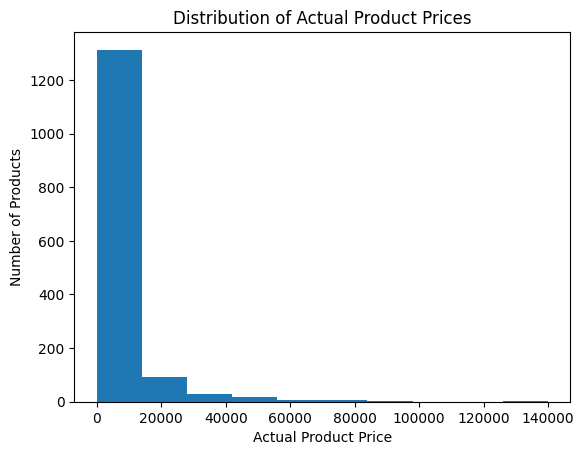

In [55]:
plt.hist(products_df['actual_price'],bins=10)
plt.xlabel('Actual Product Price')
plt.ylabel("Number of Products")
plt.title("Distribution of Actual Product Prices")
plt.show()


What are the most expensive and cheapest products?

In [56]:
products_df.sort_values("actual_price",ascending=False).head(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,img_link,product_link,main_category,sub_category_1,sub_category_2,sub_category_3,sub_category_4
249,B09WN3SRC7,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,"Electronics|HomeTheater,TV&Video|Televisions|S...",77990.0,139900.0,0.44,4.7,5935.0,Resolution: 4K Ultra HD (3840 x 2160) | Refres...,https://m.media-amazon.com/images/I/51uVckL1jR...,https://www.amazon.in/Sony-Bravia-inches-Googl...,Electronics,"HomeTheater,TV&Video",Televisions,SmartTelevisions,NaN
255,B0BC8BQ432,VU 164 cm (65 inches) The GloLED Series 4K Sma...,"Electronics|HomeTheater,TV&Video|Televisions|S...",54990.0,85000.0,0.35,4.3,3587.0,Resolution: 4K Ultra HD (3840x2160) | Refresh ...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/VU-inches-GloLED-Google-...,Electronics,"HomeTheater,TV&Video",Televisions,SmartTelevisions,NaN
283,B0B3XXSB1K,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,"Electronics|HomeTheater,TV&Video|Televisions|S...",47990.0,79990.0,0.40,4.3,1376.0,Resolution: 4K Ultra HD (3840x2160) | Refresh ...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/LG-inches-Ultra-55UQ7500...,Electronics,"HomeTheater,TV&Video",Televisions,SmartTelevisions,NaN
1354,B09NS5TKPN,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,"Home&Kitchen|Heating,Cooling&AirQuality|AirCon...",42990.0,75990.0,0.43,4.3,3231.0,Split AC with inverter compressor: variable sp...,https://m.media-amazon.com/images/I/21ywp-zfTj...,https://www.amazon.in/LG-Convertible-Anti-Viru...,Home&Kitchen,"Heating,Cooling&AirQuality",AirConditioners,Split-SystemAirConditioners,NaN
568,B08VB57558,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics|Mobiles&Accessories|Smartphones&Ba...,37990.0,74999.0,0.49,4.2,27790.0,5G Ready powered by Qualcomm Snapdragon 865 Oc...,https://m.media-amazon.com/images/I/41ezRvTwca...,https://www.amazon.in/Samsung-Galaxy-Cloud-128...,Electronics,Mobiles&Accessories,Smartphones&BasicMobiles,Smartphones,NaN


How much discount is applied across products?

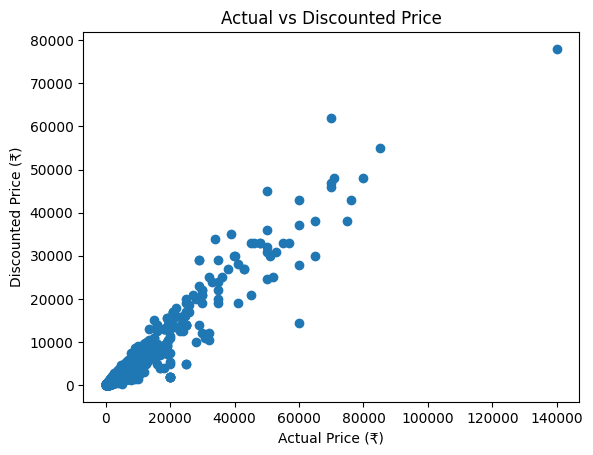

In [57]:
plt.scatter(products_df["actual_price"], products_df["discounted_price"])
plt.xlabel("Actual Price (₹)")
plt.ylabel("Discounted Price (₹)")
plt.title("Actual vs Discounted Price")
plt.show()


What discounts are most common?

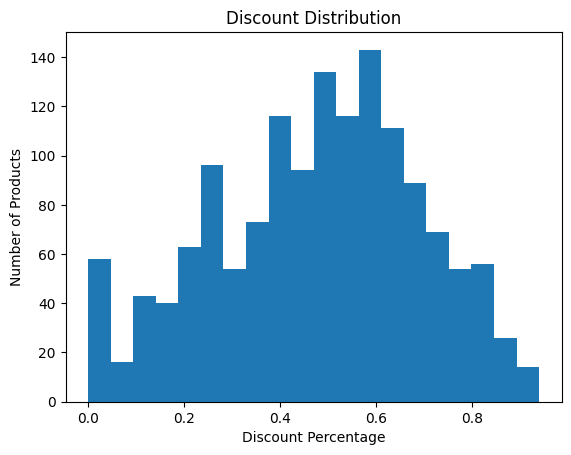

In [58]:
plt.hist(products_df["discount_percentage"].dropna(), bins=20)
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")
plt.title("Discount Distribution")
plt.show()


Rating Analysis

Are most products well-rated?

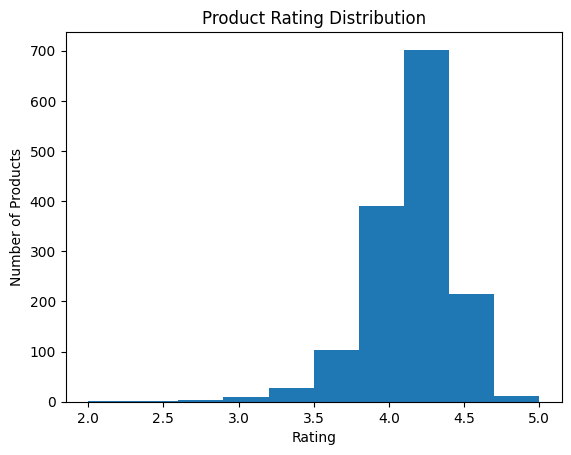

In [59]:
plt.hist(products_df["rating"].dropna(), bins=10)
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.title("Product Rating Distribution")

plt.show()


 What are the top 10 most rated products


In [60]:
products_df.sort_values("rating_count", ascending=False).head(10)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,img_link,product_link,main_category,sub_category_1,sub_category_2,sub_category_3,sub_category_4
12,B07KSMBL2H,AmazonBasics Flexible Premium HDMI Cable (Blac...,"Electronics|HomeTheater,TV&Video|Accessories|C...",219.0,700.0,0.69,4.4,426973.0,"Flexible, lightweight HDMI cable for connectin...",https://m.media-amazon.com/images/I/41nPYaWA+M...,https://www.amazon.in/AmazonBasics-Flexible-HD...,Electronics,"HomeTheater,TV&Video",Accessories,Cables,HDMICables
65,B014I8SX4Y,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...","Electronics|HomeTheater,TV&Video|Accessories|C...",309.0,1400.0,0.78,4.4,426973.0,HDMI A Male to A Male Cable: Supports Ethernet...,https://m.media-amazon.com/images/I/41eJqkFjCR...,https://www.amazon.in/AmazonBasics-High-Speed-...,Electronics,"HomeTheater,TV&Video",Accessories,Cables,HDMICables
47,B014I8SSD0,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...","Electronics|HomeTheater,TV&Video|Accessories|C...",309.0,475.0,0.35,4.4,426973.0,Please select appropriate display resolution &...,https://m.media-amazon.com/images/I/41bCxnHksn...,https://www.amazon.in/AmazonBasics-High-Speed-...,Electronics,"HomeTheater,TV&Video",Accessories,Cables,HDMICables
684,B07KSMBL2H,AmazonBasics Flexible Premium HDMI Cable (Blac...,"Electronics|HomeTheater,TV&Video|Accessories|C...",219.0,700.0,0.69,4.4,426972.0,"Flexible, lightweight HDMI cable for connectin...",https://m.media-amazon.com/images/I/41nPYaWA+M...,https://www.amazon.in/AmazonBasics-Flexible-HD...,Electronics,"HomeTheater,TV&Video",Accessories,Cables,HDMICables
400,B07GQD4K6L,boAt Bassheads 100 in Ear Wired Earphones with...,"Electronics|Headphones,Earbuds&Accessories|Hea...",379.0,999.0,0.62,4.1,363713.0,The perfect way to add some style and stand ou...,https://m.media-amazon.com/images/I/31qVddHyy5...,https://www.amazon.in/Boat-BassHeads-100-Inspi...,Electronics,"Headphones,Earbuds&Accessories",Headphones,In-Ear,NaN
352,B07GPXXNNG,boAt Bassheads 100 in Ear Wired Earphones with...,"Electronics|Headphones,Earbuds&Accessories|Hea...",349.0,999.0,0.65,4.1,363713.0,The perfect way to add some style and stand ou...,https://m.media-amazon.com/images/I/31J6I7SrLX...,https://www.amazon.in/Boat-BassHeads-100-Inspi...,Electronics,"Headphones,Earbuds&Accessories",Headphones,In-Ear,NaN
584,B071Z8M4KX,boAt BassHeads 100 in-Ear Wired Headphones wit...,"Electronics|Headphones,Earbuds&Accessories|Hea...",365.0,999.0,0.63,4.1,363711.0,The perfect way to add some style and stand ou...,https://m.media-amazon.com/images/I/31IdiM9ZM8...,https://www.amazon.in/boAt-BassHeads-100-Headp...,Electronics,"Headphones,Earbuds&Accessories",Headphones,In-Ear,NaN
371,B09GFLXVH9,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",Electronics|Mobiles&Accessories|Smartphones&Ba...,6499.0,8499.0,0.24,4.1,313836.0,Processor: MediaTek Helio G25 Octa-core; Up to...,https://m.media-amazon.com/images/I/41i7LM0pGw...,https://www.amazon.in/Redmi-9A-Sport-Octa-core...,Electronics,Mobiles&Accessories,Smartphones&BasicMobiles,Smartphones,NaN
370,B09GFPVD9Y,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",Electronics|Mobiles&Accessories|Smartphones&Ba...,8499.0,10999.0,0.23,4.1,313836.0,Processor: Octa-core Helio G35 and upto 2.3GHz...,https://m.media-amazon.com/images/I/416SpYgTVY...,https://www.amazon.in/Redmi-Activ-Carbon-Black...,Electronics,Mobiles&Accessories,Smartphones&BasicMobiles,Smartphones,NaN
566,B09GFPN6TP,"Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...",Electronics|Mobiles&Accessories|Smartphones&Ba...,7499.0,9499.0,0.21,4.1,313832.0,Processor: MediaTek Helio G25 Octa-core; Up to...,https://m.media-amazon.com/images/I/41i7LM0pGw...,https://www.amazon.in/Redmi-9A-Sport-Octa-core...,Electronics,Mobiles&Accessories,Smartphones&BasicMobiles,Smartphones,NaN


Do expensive products get better ratings?

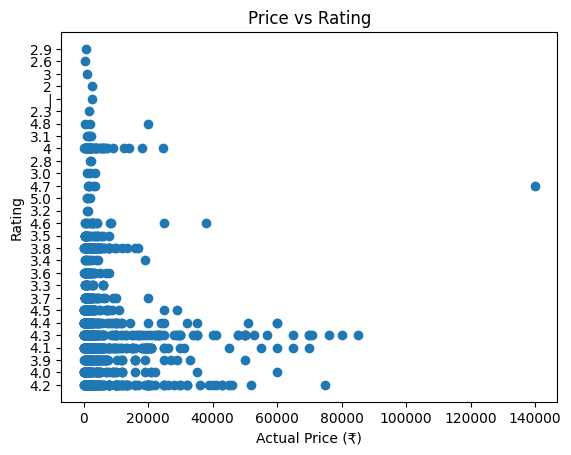

In [61]:
plt.scatter(products_df["actual_price"], df["rating"])
plt.xlabel("Actual Price (₹)")
plt.ylabel("Rating")
plt.title("Price vs Rating")

plt.show()


Category-Based Insights

what are the average price per category?

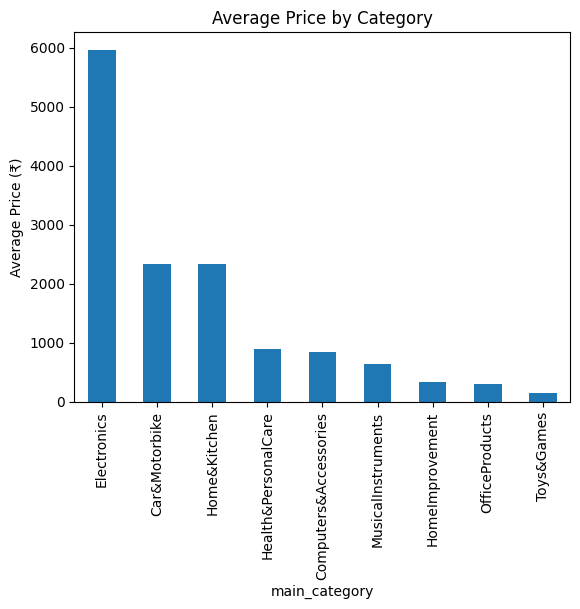

In [62]:
products_df.groupby("main_category")["discounted_price"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.ylabel("Average Price (₹)")
plt.title("Average Price by Category")

plt.show()


Which categories offer the highest discounts?

In [63]:
discount_by_cat = (
    products_df.groupby("main_category")["discount_percentage"]
      .mean()
      .sort_values(ascending=False)
)

discount_by_cat.head(10)

,discount_percentage
main_category,
HomeImprovement,0.575000
Computers&Accessories,0.540243
Health&PersonalCare,0.530000
Electronics,0.508289
MusicalInstruments,0.460000
Car&Motorbike,0.420000
Home&Kitchen,0.401205
OfficeProducts,0.123548
Toys&Games,0.000000


## **STATISTICAL TESTS**

In [82]:
import scipy.stats as stats
# t-test to compare rating between two categories
t_statistic, p_value = stats.ttest_ind(products_df[products_df['main_category'] == 'electronics']['rating'], products_df[products_df['main_category'] == 'clothing']['rating'])

# Print t-statistic and p-value
print(t_statistic, p_value)

nan nan


In [84]:
# Chi-square test

# Create a contigency table
contigency_table = pd.crosstab(products_df['actual_price'], products_df['rating'])
contigency_table

rating,2.0,2.3,2.6,2.8,2.9,3.0,3.1,3.2,3.3,3.4,...,4.0,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,5.0
actual_price,,,,,,,,,,,,,,,,,,,,,
39.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
59.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
75.0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
79.0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74999.0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
75990.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
79990.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [85]:
# perform chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contigency_table)

# print the results
print('Chi-square statistic:', chi2)
print('p-value:', p)
print('Degrees of freedom:', dof)
print(f"Expected:\n {expected}")

Chi-square statistic: 8635.264277480239
p-value: 1.0
Degrees of freedom: 10752
Expected:
 [[0.00136519 0.00136519 0.00136519 ... 0.00819113 0.00409556 0.00409556]
 [0.00068259 0.00068259 0.00068259 ... 0.00409556 0.00204778 0.00204778]
 [0.00068259 0.00068259 0.00068259 ... 0.00409556 0.00204778 0.00204778]
 ...
 [0.00068259 0.00068259 0.00068259 ... 0.00409556 0.00204778 0.00204778]
 [0.00068259 0.00068259 0.00068259 ... 0.00409556 0.00204778 0.00204778]
 [0.00068259 0.00068259 0.00068259 ... 0.00409556 0.00204778 0.00204778]]


## **SENTIMENT ANALYSIS**

In [64]:
!pip install textblob


In [65]:
from textblob import TextBlob


In [66]:
reviews_df['review_content'][0]

'Looks durable Charging is fine tooNo complains,Charging is really fast, good product.,Till now satisfied with the quality.,This is a good product . The charging speed is slower than the original iPhone cable,Good quality, would recommend,https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/81---F1ZgHL._SY88.jpg,Product had worked well till date and was having no issue.Cable is also sturdy enough...Have asked for replacement and company is doing the same...,Value for money'

In [67]:
import re

#Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)        # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)       # keep letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [68]:
reviews_df['clean_review'] = reviews_df['review_content'].apply(clean_text)


Compute polarity

In [69]:
reviews_df['polarity'] = reviews_df['clean_review'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

reviews_df['subjectivity'] = reviews_df['clean_review'].apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)


In [70]:
def label_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

reviews_df['sentiment_label'] = reviews_df['polarity'].apply(label_sentiment)


Sentiment per product

In [71]:
product_sentiment = (
    reviews_df.groupby('product_id')
      .agg(
          avg_polarity=('polarity', 'mean'),
          positive_ratio=('sentiment_label', lambda x: (x == 'Positive').mean()),
          review_count=('review_id', 'count')
      )
      .reset_index()
)


In [72]:
# Summary

sentiment_counts = reviews_df['sentiment_label'].value_counts()
print("Sentiment distribution:")
print(sentiment_counts)
print(f"\nPositive review percentage: {(sentiment_counts.get('Positive', 0) / len(reviews_df)) * 100:.1f}%")

Sentiment distribution:
sentiment_label
Positive    1362
Neutral       97
Negative       6
Name: count, dtype: int64

Positive review percentage: 93.0%


In [73]:
reviews_df.head(5)

,product_id,review_id,user_id,user_name,review_title,review_content,clean_review,polarity,subjectivity,sentiment_label
0,B07JW9H4J1,"R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,looks durable charging is fine toono complains...,0.481944,0.675000,Positive
1,B098NS6PVG,"RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,i ordered this cable to connect my phone to an...,0.274318,0.509394,Positive
2,B096MSW6CT,"R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",not quite durable and sturdy good nice product...,0.633333,0.866667,Positive
3,B08HDJ86NZ,"R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",good productlong wirecharges goodnicei bought ...,0.240370,0.544444,Positive
4,B08CF3B7N1,"R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",bought this instead of original apple does the...,0.262740,0.642634,Positive
